### **RNN/LSTM**

Цель семинара: получить практический опыт работы с RNN (LSTM) в PyTorch на задачах генерации последовательностей

Мы разберем полный пайплайн разработки от препроцессинга данных до обучения и экспериментов с гиперпараметрами

Кстати, что мы называем **пайплайном**?

В Google Colab (рекомендуется активировать GPU: `Среда выполнения → Сменить среду выполнения → T4 GPU`)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

## **ЧАСТЬ 1: ДЕМО**
*   **Задача модели:** предсказание случайного временного ряда (синусоида)
*   **Цель демонстрации:** показать полный и минимальный рабочий пайплайн RNN на задаче, связанной с обработкой данных, передающих изменения во времени
*   **План:**
    1.  Подготовка последовательностей (sequences)
    2.  Архитектура `nn.LSTM`
    3.  Обучение модели
    4.  Получение метрик оценки
    5.  Визуализация и интерпретация результата

### 1. ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ

In [28]:
def generate_sine_wave(seq_length=1000, periods=5):
    """Генерация синусоиды."""
    x = np.linspace(0, periods * 2 * np.pi, seq_length)
    y = np.sin(x)
    return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

Длина временного ряда: 1000


In [29]:
# Параметры последовательностей
SEQ_LEN = 50  # Длина входной последовательности для предсказания
BATCH_SIZE = 16

In [30]:
def create_sequences(data, seq_len):
    """Создание пар (входная последовательность, целевое значение)."""
    sequences = []
    targets = []
    for i in range(len(data) - seq_len - 1):
        seq = data[i:i + seq_len]
        target = data[i + seq_len]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

In [31]:
# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")

Форма X (последовательности): (949, 50)
Форма y (цели): (949,)


In [32]:
# Преобразование в тензоры PyTorch и добавление размерности для признаков
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [примеры, SEQ_LEN, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [примеры, 1]
print(f"Форма X (тензор): {X.shape}")
print(f"Форма y (тензор): {y.shape}")

Форма X (тензор): torch.Size([949, 50, 1])
Форма y (тензор): torch.Size([949, 1])


In [33]:
# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [34]:
### 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # формат [batch, seq_len, features]
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Инициализация скрытого состояния и состояния ячейки
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Берем только последний выход последовательности для предсказания
        out = self.fc(out[:, -1, :])
        return out

In [35]:
# Инициализация модели
model = SineLSTM()
print(f"Модель:\n{model}")

Модель:
SineLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### 3. ОБУЧЕНИЕ МОДЕЛИ

In [36]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 0.01

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Тренировочный цикл
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()

    # Прямой проход
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Обратное распространение
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха [{epoch+1}/{EPOCHS}], '
              f'Ошибка обучения: {loss.item():.6f}, '
              f'Ошибка теста: {test_loss.item():.6f}')

Эпоха [5/20], Ошибка обучения: 0.307647, Ошибка теста: 0.061842
Эпоха [10/20], Ошибка обучения: 0.094273, Ошибка теста: 0.070605
Эпоха [15/20], Ошибка обучения: 0.051351, Ошибка теста: 0.051860
Эпоха [20/20], Ошибка обучения: 0.020821, Ошибка теста: 0.024741


### 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

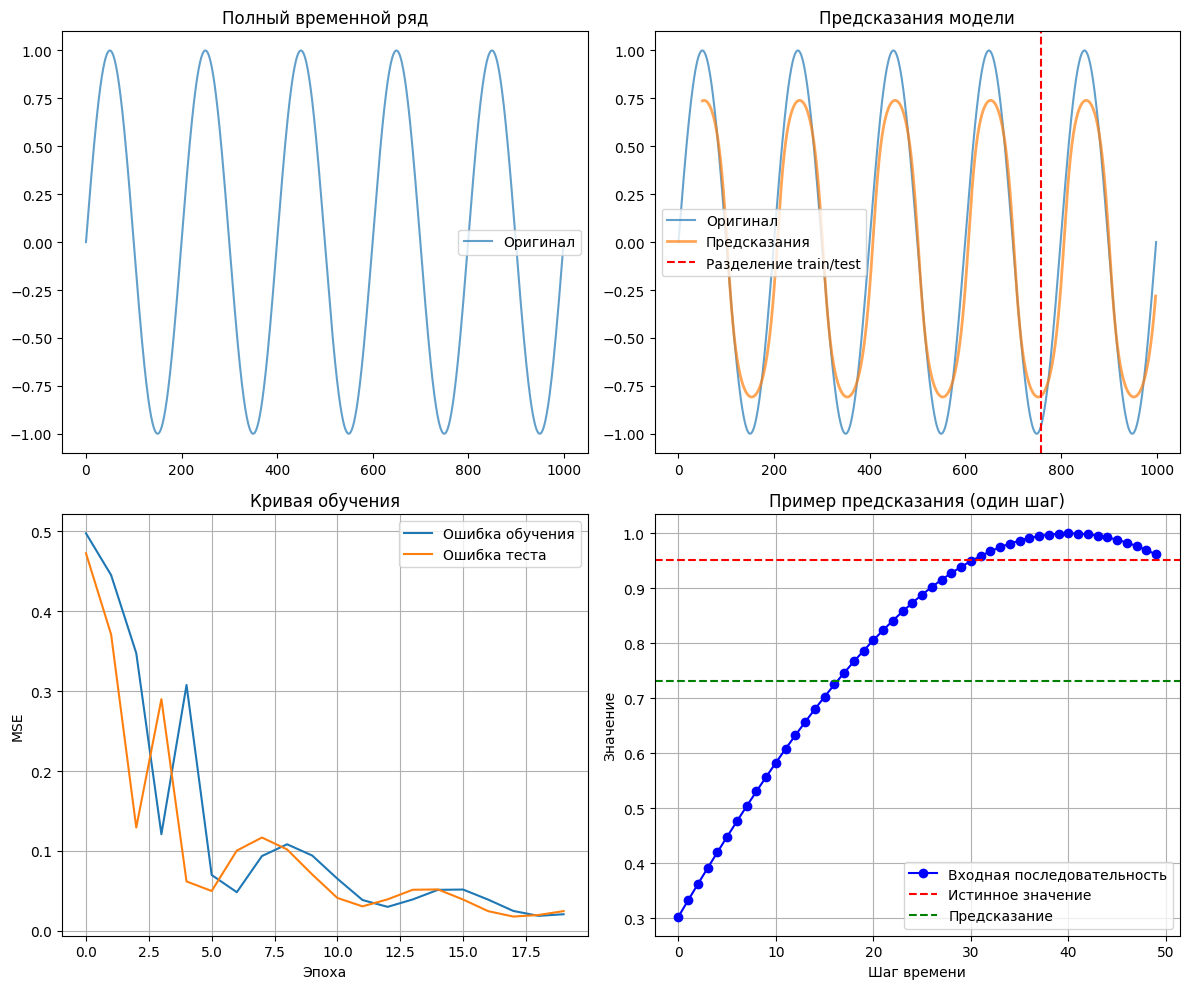

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Оригинальные данные и предсказания
axes[0, 0].plot(data, label='Оригинал', alpha=0.7)
axes[0, 0].set_title('Полный временной ряд')
axes[0, 0].legend()

# График 2: Предсказания на тестовой выборке
model.eval()
with torch.no_grad():
    all_predictions = model(X).numpy()

# Создание массива для отображения предсказаний
pred_series = np.full_like(data, np.nan)
pred_series[SEQ_LEN:SEQ_LEN + len(all_predictions)] = all_predictions.squeeze()

axes[0, 1].plot(data, label='Оригинал', alpha=0.7)
axes[0, 1].plot(pred_series, label='Предсказания', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=split_idx, color='r', linestyle='--', label='Разделение train/test')
axes[0, 1].set_title('Предсказания модели')
axes[0, 1].legend()

# График 3: Ошибки обучения и теста
axes[1, 0].plot(train_losses, label='Ошибка обучения')
axes[1, 0].plot(test_losses, label='Ошибка теста')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Кривая обучения')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График 4: Пример одного предсказания
sample_idx = split_idx + 50
axes[1, 1].plot(range(SEQ_LEN), X[sample_idx].squeeze().numpy(),
                'bo-', label='Входная последовательность')
axes[1, 1].axhline(y=y[sample_idx].item(), color='r', linestyle='--',
                   label='Истинное значение')
axes[1, 1].axhline(y=all_predictions[sample_idx].item(), color='g',
                   linestyle='--', label='Предсказание')
axes[1, 1].set_xlabel('Шаг времени')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Пример предсказания (один шаг)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Кривая обучения должна снижаться на обеих выборках
2. Предсказания должны следовать за оригинальным рядом
3. Разрыв между train/test loss указывает на переобучение
4. Модель учится предсказывать следующий шаг синусоиды

Take aways:

1. Подготовка последовательностей: как из временного ряда создаются пары (окно истории -> целевое значение)?

2. Архитектура LSTM: batch_first=True, почему берем out[:, -1, :]

3. Цикл обучения: разделение на model.train() и model.eval(), логика .zero_grad(), .backward(), .step()

4. Визуализация: как интерпретировать каждый из 4-х графиков?

---

# ПРАКТИКА

1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/reuters/load_data

In [5]:
# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [6]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])


Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [8]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

Общая длина текста (символов): 815340
Пример текста: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 


In [9]:
# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
print(chars)

[' ', "'", '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [10]:
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

Размер словаря (уникальных символов): 39


In [11]:
idx_to_char

{0: ' ',
 1: "'",
 2: '0',
 3: '1',
 4: '2',
 5: '3',
 6: '4',
 7: '5',
 8: '6',
 9: '7',
 10: '8',
 11: '9',
 12: '?',
 13: 'a',
 14: 'b',
 15: 'c',
 16: 'd',
 17: 'e',
 18: 'f',
 19: 'g',
 20: 'h',
 21: 'i',
 22: 'j',
 23: 'k',
 24: 'l',
 25: 'm',
 26: 'n',
 27: 'o',
 28: 'p',
 29: 'q',
 30: 'r',
 31: 's',
 32: 't',
 33: 'u',
 34: 'v',
 35: 'w',
 36: 'x',
 37: 'y',
 38: 'z'}

In [12]:
# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
texts[:10], text_as_int[:10]

('? mcgrath ', [12, 0, 25, 15, 19, 30, 13, 32, 20, 0])

In [13]:
text_as_int = np.array(text_as_int)

text_as_int

array([12,  0, 25, ..., 30,  0,  5])

4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [14]:
seq_length = 100

In [15]:
# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

/tmp/ipython-input-548/2203781802.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)


In [16]:
input_seq

tensor([[12,  0, 25,  ..., 17, 30,  0],
        [ 0, 25, 15,  ..., 30,  0, 31],
        [25, 15, 19,  ...,  0, 31, 20],
        ...,
        [26, 21, 26,  ..., 33, 32, 17],
        [21, 26, 17,  ..., 32, 17, 30],
        [26, 17,  0,  ..., 17, 30,  0]])

In [17]:
target_seq

tensor([31, 20, 13,  ..., 30,  0,  5])

In [18]:
print(f"Количество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240])


In [19]:
# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [20]:
dataset

In [21]:
dataloader

5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [42]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=0.2,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):

        embedded = self.embedding(x)

        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        lstm_out = lstm_out[:, -1, :]

        output = self.fc(lstm_out)

        return output, hidden

device = torch.device('cuda')

6. ОБУЧЕНИЕ МОДЕЛИ

In [43]:
def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text


    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]

    with torch.no_grad():
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            next_char_idx = torch.multinomial(probabilities, 1).item()

            generated += idx_to_char[next_char_idx]

            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 28 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

In [44]:
EPOCHS = 4
models_losses = []

for hs, nl, lr in zip([64, 256, 512], [1, 2, 3], [0.01, 0.001, 0.005]):
    model = CharLSTM(vocab_size=vocab_size, hidden_size=hs, num_layers=nl)
    model = model.to(device)
    print(f"\nМодель:\n{model}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []

    print("\nНачало обучения...")
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        batch_count = len(dataloader)

        for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()

            output, _ = model(batch_input)
            loss = criterion(output, batch_target)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

            if (batch_idx + 1) % 50 == 0:
                avg_batch_loss = loss.item()
                print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

        avg_loss = total_loss / len(dataloader)
        train_losses.append(avg_loss)

        if (epoch + 1) % 2 == 0:
            seed = "the company said"
            safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
            if len(safe_seed) > 0:
                generated = generate_text(model, safe_seed, length=50, temperature=0.8)
                print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
                print(f'Сгенерированный текст: "{generated}"')
            else:
                print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
                print('Не удалось сгенерировать текст: seed содержит неизвестные символы')
    models_losses.append(train_losses)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Streaming output truncated to the last 5000 lines.
Эпоха [3/4], Батч [6200/25477], Потеря: 2.1301
Эпоха [3/4], Батч [6250/25477], Потеря: 1.9819
Эпоха [3/4], Батч [6300/25477], Потеря: 1.5521
Эпоха [3/4], Батч [6350/25477], Потеря: 1.9698
Эпоха [3/4], Батч [6400/25477], Потеря: 1.9057
Эпоха [3/4], Батч [6450/25477], Потеря: 1.6563
Эпоха [3/4], Батч [6500/25477], Потеря: 1.7896
Эпоха [3/4], Батч [6550/25477], Потеря: 2.2137
Эпоха [3/4], Батч [6600/25477], Потеря: 1.9258
Эпоха [3/4], Батч [6650/25477], Потеря: 1.8757
Эпоха [3/4], Батч [6700/25477], Потеря: 2.0728
Эпоха [3/4], Батч [6750/25477], Потеря: 1.4529
Эпоха [3/4], Батч [6800/25477], Потеря: 1.5821
Эпоха [3/4], Батч [6850/25477], Потеря: 1.6346
Эпоха [3/4], Батч [6900/25477], Потеря: 1.8959
Эпоха [3/4], Батч [6950/25477], Потеря: 2.0131
Эпоха [3/4], Батч [7000/25477], Потеря: 1.7159
Эпоха [3/4], Батч [7050/25477], Потеря: 1.9591
Эпоха [3/4], Батч [7100/25477], Потеря: 1.6088
Эпоха [3/4], Батч [7150/25477], Потеря: 2.0797
Эпоха [3/

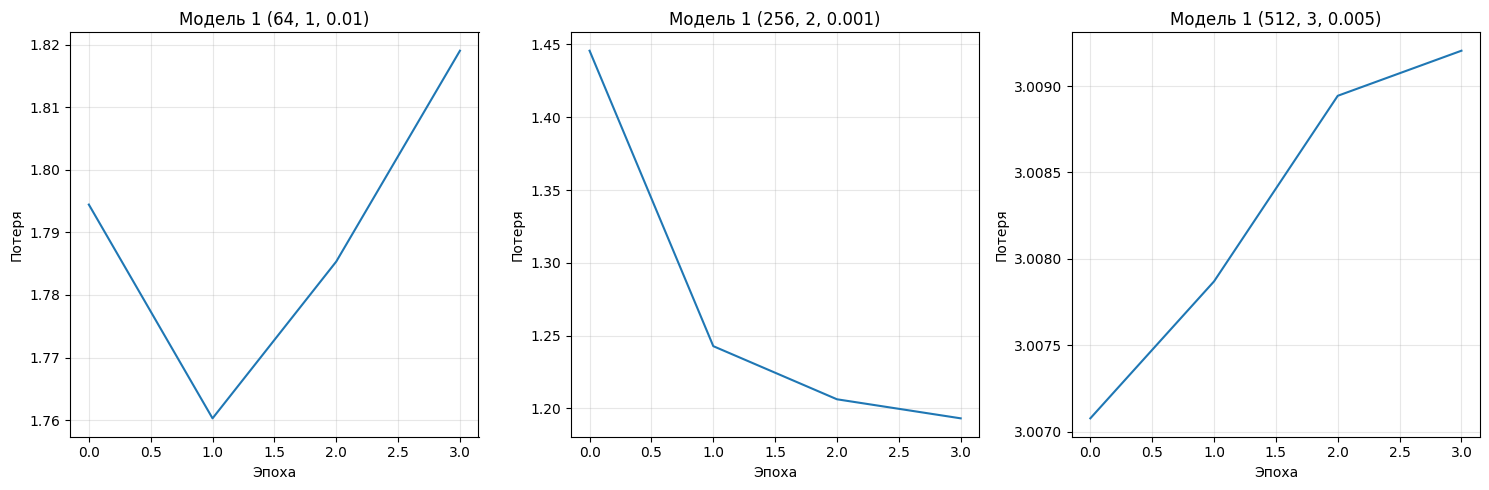

In [45]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(models_losses[0])
axes[0].set_title('Модель 1 (64, 1, 0.01)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потеря')
axes[0].grid(True, alpha=0.3)

axes[1].plot(models_losses[1])
axes[1].set_title('Модель 1 (256, 2, 0.001)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Потеря')
axes[1].grid(True, alpha=0.3)

axes[2].plot(models_losses[2])
axes[2].set_title('Модель 1 (512, 3, 0.005)')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Потеря')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

I) Сравните:


---


1. Скорость сходимости (график loss).

Для первой модели выбран слишком большой шаг, поэтому после первой эпохи ошибки начинают расти. 3 модель показала худший результат, ошибки стабильно росли, видимо шаг тоже слишком велик для такого объема данных. 2 модель показала лучший результат, стабильно снижая ошибки.


---


2. Качество генерации (осмысленность текста).
Результаты выдачи:
1) the company said export compect their oan dlr fis bubillion the 1
2) the company said it were pakments by 6 2 mln bushels predicted to
3) the company saidn san eahrv?ena  oetto nenr loa      c nthoeg  imf

В целом, все результаты неудовлетворительные. 3 очевидно наименее связный и осмысленный. 1 и 2 примерно на одном уровне.


---


3. Время обучения.

Первая модель обучалась 5 минут, вторая - около 19 минут, третья обучалась 1 час и 21 минуту.


---



### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?

Ответ: Основным отличием является преобразование слов в числовые данные в случае с подготовкой данных для текста, что усложняет задачу, так как приходится преобразовывать данные в векторы и обратно.

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

Ответ: Подбор параметров с дальнейшей визуализацией показался наиболее полезным, так как это дает более ясное представление о том, как модель работает в целом, и как на ее работу влияет каждый отдельно взятый параметр.